# Machine Learning

## Data Preprocessing Practice

Adımlar:
  1. kütüphaneleri içeri aktar
  2. csv dosyasını yükle ve veriyi incele
  3. eksik verilerin gösterilmesi drop ile çıkartma ve median ile doldurma
  4. label encoding ve one hot encoding
  5. sayısal sütunlara standardization ve normalization
  6. train test split ile verinin 2 ye ayrılması

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv("customer_data_ml_practice.csv")
df.head()

,age,salary,city,education,experience_years,purchased
0,25.0,32000.0,Ankara,Bachelors,1.0,Yes
1,31.0,41000.0,Istanbul,Masters,4.0,No
2,28.0,NaN,Izmir,Bachelors,2.0,Pending
3,45.0,67000.0,Ankara,PhD,15.0,No
4,NaN,52000.0,Bursa,Bachelors,7.0,Yes


In [3]:
df.isnull().sum()

age                 1
salary              1
city                0
education           1
experience_years    1
purchased           0
dtype: int64

In [4]:
df_dropna = df.dropna()
df_dropna

,age,salary,city,education,experience_years,purchased
0,25.0,32000.0,Ankara,Bachelors,1.0,Yes
1,31.0,41000.0,Istanbul,Masters,4.0,No
3,45.0,67000.0,Ankara,PhD,15.0,No
5,36.0,48000.0,Istanbul,Associate Degree,6.0,Pending
7,41.0,61000.0,Ankara,Masters,11.0,No
8,33.0,45000.0,Bursa,Bachelors,5.0,Pending
10,38.0,56000.0,Izmir,Masters,9.0,Yes
11,30.0,43000.0,Ankara,Bachelors,3.0,Pending


In [5]:
df_filled = df.copy()
numerical_columns = ["age", "salary", "experience_years"]

for col in numerical_columns:
    df_filled[col] = df_filled[col].fillna(df_filled[col].median())

In [6]:
df_filled

,age,salary,city,education,experience_years,purchased
0,25.0,32000.0,Ankara,Bachelors,1.0,Yes
1,31.0,41000.0,Istanbul,Masters,4.0,No
2,28.0,45000.0,Izmir,Bachelors,2.0,Pending
3,45.0,67000.0,Ankara,PhD,15.0,No
4,31.0,52000.0,Bursa,Bachelors,7.0,Yes
5,36.0,48000.0,Istanbul,Associate Degree,6.0,Pending
6,29.0,39000.0,Izmir,Bachelors,5.0,Yes
7,41.0,61000.0,Ankara,Masters,11.0,No
8,33.0,45000.0,Bursa,Bachelors,5.0,Pending
9,27.0,35000.0,Istanbul,NaN,2.0,No


In [7]:
df_filled["education"] = df_filled["education"].fillna(df_filled["education"].mode()[0])
df_filled

,age,salary,city,education,experience_years,purchased
0,25.0,32000.0,Ankara,Bachelors,1.0,Yes
1,31.0,41000.0,Istanbul,Masters,4.0,No
2,28.0,45000.0,Izmir,Bachelors,2.0,Pending
3,45.0,67000.0,Ankara,PhD,15.0,No
4,31.0,52000.0,Bursa,Bachelors,7.0,Yes
5,36.0,48000.0,Istanbul,Associate Degree,6.0,Pending
6,29.0,39000.0,Izmir,Bachelors,5.0,Yes
7,41.0,61000.0,Ankara,Masters,11.0,No
8,33.0,45000.0,Bursa,Bachelors,5.0,Pending
9,27.0,35000.0,Istanbul,Bachelors,2.0,No


In [8]:
# # 4. Apply Label Encoding and One-Hot Encoding
label_df = df_filled.copy()
label_encoder = LabelEncoder()
label_df["purchased_label"] = label_encoder.fit_transform(label_df["purchased"])
label_df
#

,age,salary,city,education,experience_years,purchased,purchased_label
0,25.0,32000.0,Ankara,Bachelors,1.0,Yes,2
1,31.0,41000.0,Istanbul,Masters,4.0,No,0
2,28.0,45000.0,Izmir,Bachelors,2.0,Pending,1
3,45.0,67000.0,Ankara,PhD,15.0,No,0
4,31.0,52000.0,Bursa,Bachelors,7.0,Yes,2
5,36.0,48000.0,Istanbul,Associate Degree,6.0,Pending,1
6,29.0,39000.0,Izmir,Bachelors,5.0,Yes,2
7,41.0,61000.0,Ankara,Masters,11.0,No,0
8,33.0,45000.0,Bursa,Bachelors,5.0,Pending,1
9,27.0,35000.0,Istanbul,Bachelors,2.0,No,0


In [9]:
onehot_target_df = pd.get_dummies(df["purchased"], prefix = "purchased")
onehot_target_df

,purchased_No,purchased_Pending,purchased_Yes
0,False,False,True
1,True,False,False
2,False,True,False
3,True,False,False
4,False,False,True
5,False,True,False
6,False,False,True
7,True,False,False
8,False,True,False
9,True,False,False


In [10]:
onehot_df = pd.get_dummies(df_filled, columns = ["education"], drop_first=True)
onehot_df["purchased"] = label_encoder.fit_transform(onehot_df["purchased"])
onehot_df

,age,salary,city,experience_years,purchased,education_Bachelors,education_Masters,education_PhD
0,25.0,32000.0,Ankara,1.0,2,True,False,False
1,31.0,41000.0,Istanbul,4.0,0,False,True,False
2,28.0,45000.0,Izmir,2.0,1,True,False,False
3,45.0,67000.0,Ankara,15.0,0,False,False,True
4,31.0,52000.0,Bursa,7.0,2,True,False,False
5,36.0,48000.0,Istanbul,6.0,1,False,False,False
6,29.0,39000.0,Izmir,5.0,2,True,False,False
7,41.0,61000.0,Ankara,11.0,0,False,True,False
8,33.0,45000.0,Bursa,5.0,1,True,False,False
9,27.0,35000.0,Istanbul,2.0,0,True,False,False


In [11]:
X = onehot_df.drop("purchased", axis = 1) # features
y = onehot_df["purchased"] # target


In [12]:
# 5. Standardization and Normalization only on numerical columns
numerical_features = ["age", "salary", "experience_years"]

In [13]:
X_standard = X.copy()
standard_scaler = StandardScaler()
X_standard[numerical_features] = standard_scaler.fit_transform(X_standard[numerical_features])


In [14]:
X_standard

,age,salary,city,experience_years,education_Bachelors,education_Masters,education_PhD
0,-1.357339,-1.502506,Ankara,-1.222204,True,False,False
1,-0.317675,-0.601003,Istanbul,-0.463595,False,True,False
2,-0.837507,-0.200334,Izmir,-0.969334,True,False,False
3,2.108207,2.003342,Ankara,2.317974,False,False,True
4,-0.317675,0.500835,Bursa,0.295015,True,False,False
5,0.548711,0.100167,Istanbul,0.042145,False,False,False
6,-0.664230,-0.801337,Izmir,-0.210725,True,False,False
7,1.415098,1.402339,Ankara,1.306494,False,True,False
8,0.028880,-0.200334,Bursa,-0.210725,True,False,False
9,-1.010784,-1.202005,Istanbul,-0.969334,True,False,False


In [15]:
X_normalized = X.copy()
minmax_scaler = MinMaxScaler()
X_normalized[numerical_features] = minmax_scaler.fit_transform(X_normalized[numerical_features])
X_normalized

,age,salary,city,experience_years,education_Bachelors,education_Masters,education_PhD
0,0.00,0.000000,Ankara,0.000000,True,False,False
1,0.30,0.257143,Istanbul,0.214286,False,True,False
2,0.15,0.371429,Izmir,0.071429,True,False,False
3,1.00,1.000000,Ankara,1.000000,False,False,True
4,0.30,0.571429,Bursa,0.428571,True,False,False
5,0.55,0.457143,Istanbul,0.357143,False,False,False
6,0.20,0.200000,Izmir,0.285714,True,False,False
7,0.80,0.828571,Ankara,0.714286,False,True,False
8,0.40,0.371429,Bursa,0.285714,True,False,False
9,0.10,0.085714,Istanbul,0.071429,True,False,False


In [16]:
# 6. Split the data into train and test sets using Train-test split.
X_train, X_test, y_train, y_test = train_test_split(X_standard, y, test_size = 0.2, random_state = 42)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (9, 7)
X_test (3, 7)
y_train (9,)
y_test (3,)


## Feature Engineering

Adımlar:
1. mevcut sütunlardan yeni özellikler üret (feature extraction)
2. hedef değişken ile öznitelik arasındaki korelasyonları incele
3. mutlak korelasyon değeri yüksek olan öznitelikleri seç (feature selection)

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("feature_engineering_practice.csv")
df.head()

,age,experience_years,monthly_spend,membership_duration_months,city,performance_score
0,24,1,3200,6,Ankara,58
1,27,3,4100,12,Istanbul,64
2,31,5,5200,18,Izmir,71
3,35,8,6100,24,Ankara,79
4,29,4,4700,15,Bursa,68


In [19]:
# 1. Create new features from existing columns (feature extraction)
df["experience_ratio"] = df["experience_years"] / df["age"]
df["estimated_annual_spend"] = df["monthly_spend"] * 12
df

,age,experience_years,monthly_spend,membership_duration_months,city,performance_score,experience_ratio,estimated_annual_spend
0,24,1,3200,6,Ankara,58,0.041667,38400
1,27,3,4100,12,Istanbul,64,0.111111,49200
2,31,5,5200,18,Izmir,71,0.161290,62400
3,35,8,6100,24,Ankara,79,0.228571,73200
4,29,4,4700,15,Bursa,68,0.137931,56400
5,42,14,7600,40,Istanbul,88,0.333333,91200
6,38,11,6900,32,Izmir,84,0.289474,82800
7,26,2,3600,8,Ankara,61,0.076923,43200
8,33,7,5900,20,Bursa,75,0.212121,70800
9,45,16,8100,46,Istanbul,91,0.355556,97200


In [20]:
# 2. Examine correlations between features and the target variable
numerical_df = df.drop("city", axis = 1)
correlations = numerical_df.corr()["performance_score"].sort_values(ascending = False)
correlations

performance_score             1.000000
estimated_annual_spend        0.998033
monthly_spend                 0.998033
experience_ratio              0.997640
age                           0.991814
experience_years              0.985984
membership_duration_months    0.982116
Name: performance_score, dtype: float64

In [21]:
# 3. Select features with high absolute correlation values (feature selection)
selected_features = correlations[abs(correlations) > 0.995].index.tolist()
selected_features.remove("performance_score")
selected_features

['estimated_annual_spend', 'monthly_spend', 'experience_ratio']

In [22]:
"""
Cross-Validation Methods Practice

Amaç:
    1. Apply K-Fold, Stratified K-Fold, and Leave-One-Out methods aynı veri seti üzerinde uygulamak.
    2. Show the evaluation logic of these three methods comparatively sade ve karşılaştırmalı biçimde göstermek.

Adımlar:
    1. Gerekli kütüphaneleri içe aktaracağız.
    2. Örnek veri setini yükleyeceğiz.
    3. Basit bir sınıflandırma modeli tanımlayacağız.
    4. K-Fold ile çapraz doğrulama yapacağız.
    5. Stratified K-Fold ile çapraz doğrulama yapacağız.
    6. Leave-One-Out ile çapraz doğrulama yapacağız.
    7. Sonuçları birlikte yazdıracağız.

Kurulumlar:
    pip install scikit-learn numpy
"""

# 1. Gerekli kütüphaneleri içe aktaracağız.
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, cross_val_score

# 2. Örnek veri setini yükleyeceğiz.
X, y = load_iris(return_X_y=True)

# 3. Basit bir sınıflandırma modeli tanımlayacağız.
model = LogisticRegression(max_iter=200)

# 4. K-Fold ile çapraz doğrulama yapacağız.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

# 5. Stratified K-Fold ile çapraz doğrulama yapacağız.
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring="accuracy")

# 6. Leave-One-Out ile çapraz doğrulama yapacağız.
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=loo, scoring="accuracy")

# 7. Sonuçları birlikte yazdıracağız.
print("\nK-Fold Skorları:")
print(kfold_scores)
print("Ortalama Accuracy:", np.mean(kfold_scores).round(4))

print("\nStratified K-Fold Skorları:")
print(stratified_scores)
print("Ortalama Accuracy:", np.mean(stratified_scores).round(4))

print("\nLeave-One-Out Sonucu:")
print("Toplam Test Sayısı:", len(loo_scores))
print("Ortalama Accuracy:", np.mean(loo_scores).round(4))



K-Fold Skorları:
[1.         1.         0.93333333 0.96666667 0.96666667]
Ortalama Accuracy: 0.9733

Stratified K-Fold Skorları:
[1.         0.96666667 0.93333333 1.         0.93333333]
Ortalama Accuracy: 0.9667

Leave-One-Out Sonucu:
Toplam Test Sayısı: 150
Ortalama Accuracy: 0.9667


## Decision Trees

Amaç:
  1. iris veri setini kullanarak karar ağaçları ile sınıflandırma problemi çözme

Veri seti:
  1. 3 farklı çiçek sınıfı (etiketi):
    - setosa, versicolor, virginica
  2. Her örnek için 4 öznitelik bulunmaktadır.
    - sepal length
    - sepal width
    - petal length
    - petal width
  3. 150 tane örnek veri içermektedir.

Adımlar:
  1. veri setini yükle
  2. Feature (X) ve target (y) değişkenleri ayırma
  3. Eğitim ve test veri setlerinin oluşturulması
  4. karar ağacı modelinin oluşturulması ve eğitimi
  5. test verisi üzerinden tahmin yapılması
  6. model başarımının accuracy ile ölçülmesi
  7. Confusion matris oluşturulması ve görselleştirilmesi
  8. karar ağacının görselleştirilmesi
  9. Öznitelik önemlerinin (feauture importance) incelenmesi

kurulumlar:
pip install scikit-learn pandas matplotlib seaborn


In [23]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [24]:
# 1. veri setini yükle
iris = load_iris()

df = pd.DataFrame(
    data = iris.data,
    columns = iris.feature_names
)
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
# 2. feature ve target ayrımı
X = iris.data
y = iris.target

In [26]:
# 3. train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [27]:
# 4. karar ağacı modeli oluşturma
tree_clf = DecisionTreeClassifier(criterion = "gini", max_depth = 3, random_state = 42)
tree_clf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [28]:
# 5. test
y_pred = tree_clf.predict(X_test)

In [29]:
accuracy = accuracy_score(y_pred, y_test)
accuracy

1.0

In [30]:
# 7. confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]], dtype=int64)

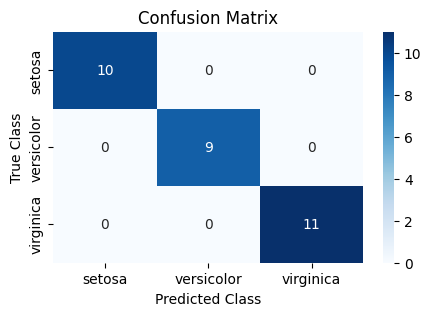

In [31]:
plt.figure(figsize=(5, 3))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

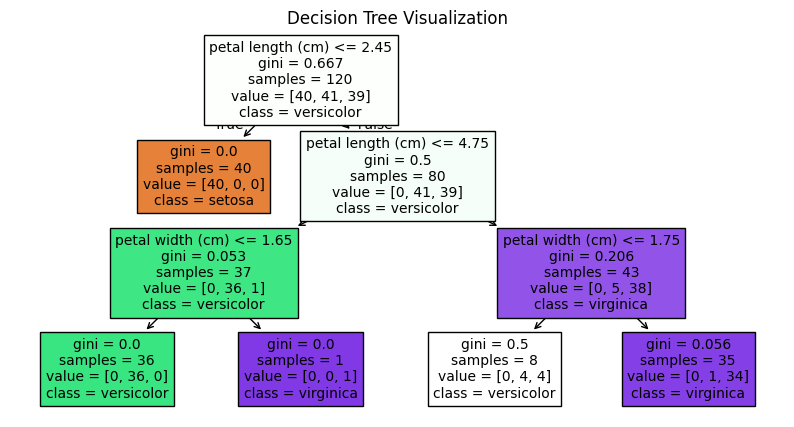

In [32]:
# 8. karar ağacının görselleştirilmesi
plt.figure(figsize=(10, 5))
plot_tree(
    tree_clf,
    filled=True,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
plt.title("Decision Tree Visualization")
plt.show()

In [33]:
# 9. feature importance
feature_importances = tree_clf.feature_importances_
feature_names = iris.feature_names

# Önem derecelerini büyükten küçüğe sıralayalım
feature_importances_sorted = sorted(
    zip(feature_importances, feature_names),
    reverse=True
)

print("\nÖzellik Önem Dereceleri:")
for importance, feature_name in feature_importances_sorted:
    print(f"{feature_name}: {importance:.4f}")


Özellik Önem Dereceleri:
petal length (cm): 0.9346
petal width (cm): 0.0654
sepal width (cm): 0.0000
sepal length (cm): 0.0000


## Clustering: K-Means Clustering

Amaç:
  - sentetik veri oluşturarak kmeans algoritması geliştirme

Veri seti:
  1. 300 samples, 2 boyutlu, 4 küme

Adımlar:
  1. Veri seti oluşturma
  2. Veri Noktalarının görselleştirilmesi
  3. K-Means modelinin tanımlanması ve eğitimi
  4. her veri noktasının ait olduğu kümenin belirlenmesi
  5. küme merkerzi görselleştir

Kurulumlar:
pip install scikit-learn matplotlib

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [35]:
# 1. Create dataset
X, _ = make_blobs(n_samples = 300, centers = 4, cluster_std = 0.6, random_state = 42)

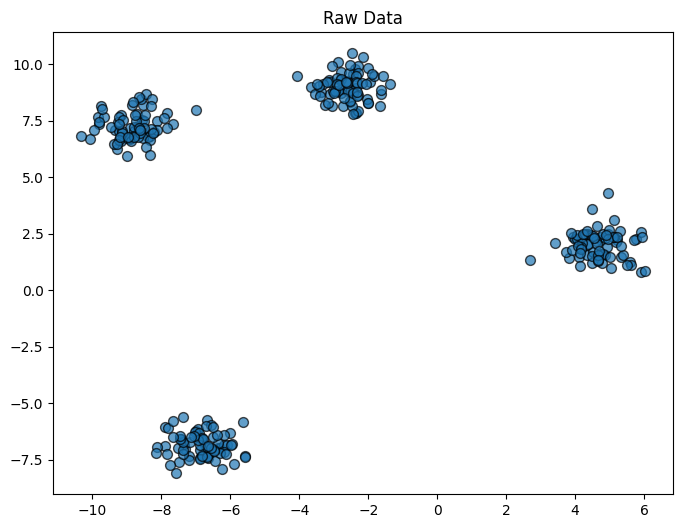

In [36]:
# 2. Visualize data points
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], s = 50, alpha = 0.7, edgecolors="k")
plt.title("Raw Data")
plt.show()

In [37]:
# 3. Define and train K-Means model
kmeans = KMeans(n_clusters = 4)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)",

In [38]:
# 4-5 Visualize cluster centers
plt.figure()
labels = kmeans.labels_

<Figure size 640x480 with 0 Axes>

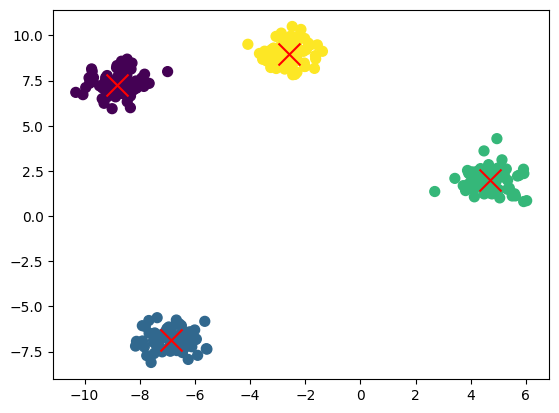

In [39]:
plt.scatter(X[:,0], X[:,1], c = labels, cmap = "viridis", s = 50)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c = "red", s = 250, marker = "x")

## Hierarchical Clustering

Amaç:
  1. sentetik bir veri oluştur ve hiyerarşik kümeleme uygula

Adımlar:
  1. veri seti oluşturma
  2. ham veri görselleştirme
  3. hiyerarşik kümeleme modeli kurma
  4. veri noktalarının ait olduğu kümeleri belirle
  5. sonuçları görselleştir
  6. dendrogram çizerek birleşme yapısını göster
  

In [40]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

In [41]:
# Create dataset
X, _ = make_blobs(n_samples = 300, centers = 4, cluster_std = 0.7, random_state = 42)

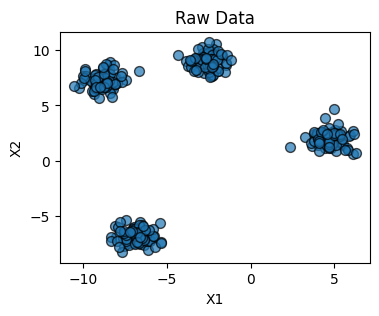

In [42]:
# 2. Raw Datayi görselleştireceğiz
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7, edgecolors="k")
plt.title("Raw Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


In [43]:
# 3. Hierarchical clustering model
model = AgglomerativeClustering(n_clusters = 4)


In [44]:
# 4. Determine cluster assignments for each data point
labels = model.fit_predict(X)

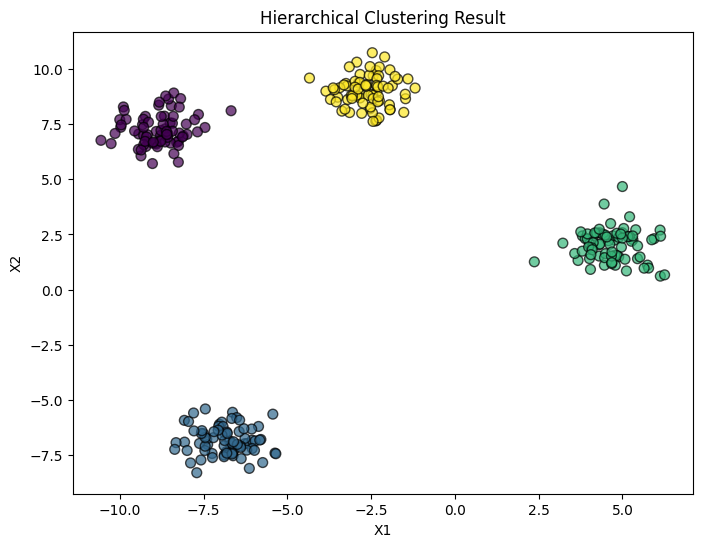

In [45]:
# 5. Visualize results with cluster colors
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=50, alpha=0.7, edgecolors="k")
plt.title("Hierarchical Clustering Result")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

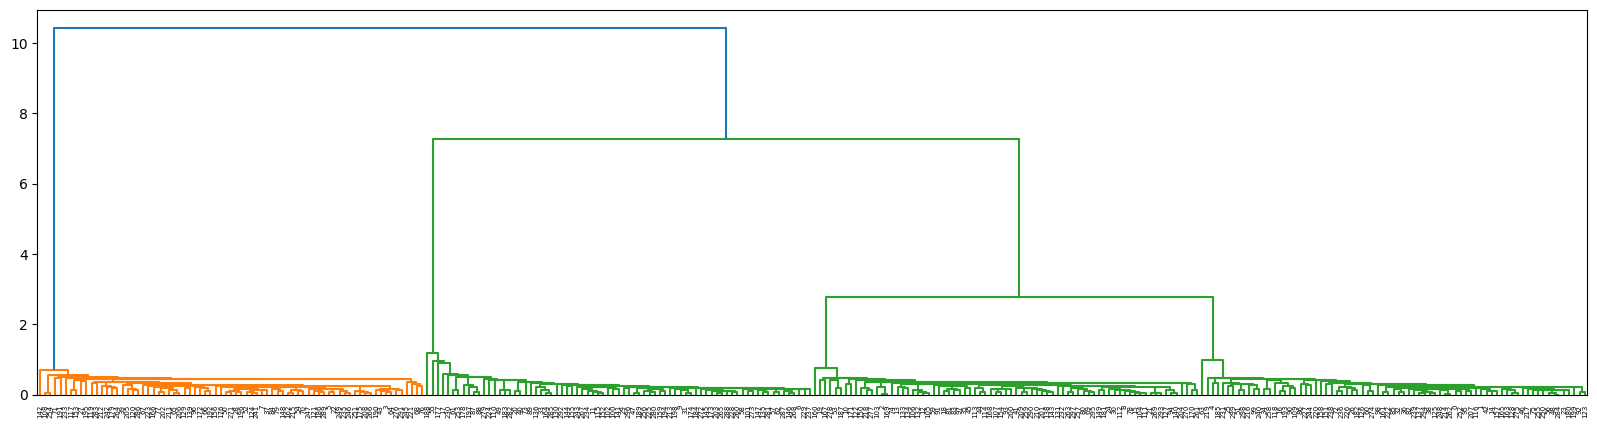

In [46]:
# 6. Dendrogram
linkage_matrix = linkage(X)

plt.figure(figsize = (20,5))
dendrogram(linkage_matrix)
plt.show()

# Dimensionality Reduction: PCA

Amaç:
  1. iris veri seti üzerinden boyut indirgeme ve görselleştirme
  2. 4 bileşenden 2 bileşene indirgeme

Adımlar:
  1. iris veri setinin yüklenmesi
  2. özellik ve target değişkenlerin tanımlanması
  3. pca modelinin 2 bileşen ile tanımlanması
  4. pca dönüşümünün uygulanması
  5. dönüştürülmüş verinin 2 boyutlu olarak görselleştirilmesi



In [47]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [48]:
iris = load_iris()
X = iris.data
y = iris.target

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

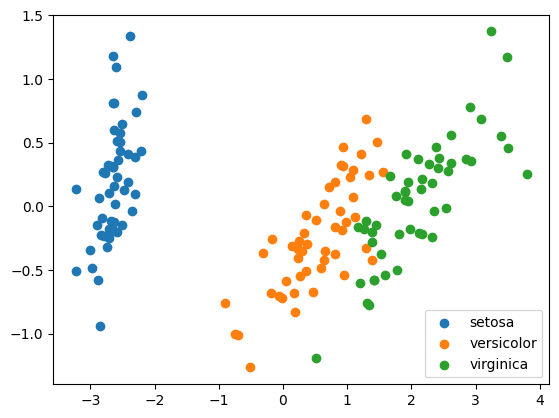

In [50]:
# Visualize data after PCA transformation
plt.figure()
for i in range(len(iris.target_names)):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label = iris.target_names[i])
plt.legend()

## Cross Validation

Amaç:
  1. Çapraz doğrulama yöntemlerini karşılaştırma

Adımlar:
  1. veri seti yükleme
  2. basit bir sınıflandırma modeli tanımlama
  3. basit bir sınıflandırma modeli tanımla
  4. kfold
  5. stratified kfold
  6. loo

In [51]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, cross_val_score

In [52]:
# örnek veri seti yükleme
X, y = load_iris(return_X_y=True)

In [53]:
model = LogisticRegression(max_iter = 200)

In [54]:
# K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")
kfold_scores

array([1.        , 1.        , 0.93333333, 0.96666667, 0.96666667])

In [55]:
# Stratified K-Fold
stratified_kfold = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
stratified_kfold_scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring="accuracy")
stratified_kfold_scores

array([1.        , 0.96666667, 0.93333333, 1.        , 0.93333333])

In [56]:
# Stratified K-Fold
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=loo, scoring="accuracy")
loo_scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Hyperparameter Tuning

Amaç:
  1. KNN, Decision Tree ve Logistic Regression modelleri için Grdi search ve random search uygulaması yapalım

Adımlar:
  1. örnek veri seti
  2. her model için hiperparametre uzayı belirleme
  3. grid search ile en iyi hiperparamtreleri bul
  4. random search ile en iyi hiperparamtreleri bul

In [57]:
# 1. Gerekli kütüphaneleri içe aktaracağız.
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [58]:
# 2. Örnek veri setini yükleyip eğitim ve test olarak ayıracağız.
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
# 3. Her model için hiperparametre arama uzayını tanımlayacağız.
models_and_params = {
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "grid_params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__metric": ["euclidean", "manhattan"]
        },
        "random_params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__metric": ["euclidean", "manhattan", "minkowski"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        "grid_params": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        },
        "random_params": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        }
    },
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=500, random_state=42))
        ]),
        "grid_params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        },
        "random_params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    }
}

In [60]:
results = []

# 4. Grid Search ile en iyi parametreleri bulacağız.
# 5. Random Search ile en iyi parametreleri bulacağız.
# 6. En iyi modelleri test verisi üzerinde değerlendireceğiz.
for model_name, item in models_and_params.items():
    grid_search = GridSearchCV(
        estimator=item["pipeline"],
        param_grid=item["grid_params"],
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    grid_test_score = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))

    random_search = RandomizedSearchCV(
        estimator=item["pipeline"],
        param_distributions=item["random_params"],
        n_iter=4,
        cv=3,
        scoring="accuracy",
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    random_test_score = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))

    results.append({
        "Model": model_name,
        "Yöntem": "Grid Search",
        "CV En İyi Skor": round(grid_search.best_score_, 4),
        "Test Skoru": round(grid_test_score, 4),
        "En İyi Parametreler": str(grid_search.best_params_)
    })

    results.append({
        "Model": model_name,
        "Yöntem": "Random Search",
        "CV En İyi Skor": round(random_search.best_score_, 4),
        "Test Skoru": round(random_test_score, 4),
        "En İyi Parametreler": str(random_search.best_params_)
    })

# 7. Sonuçları özet tablo halinde yazdıracağız.
results_df = pd.DataFrame(results)
results_df

C:\Users\blgnr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
12 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\blgnr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\blgnr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blgnr\AppDat

,Model,Yöntem,CV En İyi Skor,Test Skoru,En İyi Parametreler
0,KNN,Grid Search,0.9693,0.9737,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,KNN,Random Search,0.9671,0.9561,"{'model__n_neighbors': 5, 'model__metric': 'mi..."
2,Decision Tree,Grid Search,0.9363,0.9386,"{'model__criterion': 'gini', 'model__max_depth..."
3,Decision Tree,Random Search,0.9296,0.9123,"{'model__min_samples_split': 2, 'model__max_de..."
4,Logistic Regression,Grid Search,0.9802,0.9737,"{'model__C': 0.1, 'model__penalty': 'l2'}"
5,Logistic Regression,Random Search,0.9802,0.9825,"{'model__penalty': 'l2', 'model__C': 1}"
